# Phase Diagrams for Completely Miscible Alloys


In this Notebook, we will put together tools to help us calculate the Gibbs free energy of materials and use the results to construct phase diagrams.

We will use a simple model for the Gibbs free energy of the solid (S) and liquid (L) phases and describe both by the ideal solution model:
$$
\Delta G_\mathrm{mix}(x_B) = RT \left [ x_B \ln x_B +(1−x_B) \ln(1−x_B) \right ].
$$
Here, $R$ is the gas constant (8.314 J/mol/K), $T$ the absolute temperature, $x_B$ is the mole fraction of component B.

For constructing the phase diagram, we need to account for the difference in the Gibbs free energy between the solid and liquid phases for the pure components A and B. We will use a simplified thermodynamics model for the pure components that assumes a that the difference in entropy and enthalpy between the solid and liquid does not depend on temperature.

We will then use the tangent intercept construction to determine the chemical potentials for the components A and B in each phase:
$$
\mu_A = G(x_B) - x_B \frac{dG(x_B)}{d x_B}
$$
and
$$
\mu_B = G(x_B) + (1-x_B) \frac{dG(x_B)}{d x_B}.
$$

In equilibrium, the chemical potentials of a every component are the same in each phase:
$$
\mu_A^S = \mu_A^L
$$
and
$$
\mu_B^S = \mu_B^L.
$$

The mathematical solution to the chemical equilibrium condition is the common tangent construction.

--content adopted from https://github.com/MatSciEd/Thermodynamics

### Preliminaries
Import libraries.

In [1]:
# Import NumPy numerical package
import numpy as np

# Import SciPy
import scipy as scipy
from scipy.optimize import fsolve, newton

# Enable displaying of math output such as display(Math(r'Area: {}m^2 \\ Volume: {}m^3'.format(a, round(b,2), A, V)))
from IPython.display import display, Math

# plotting package
import matplotlib.pyplot as plt

import matplotlib

### Thermodynamic data
Set the thermodynamic constant and define the thermodynamic functions for the regular solution model.

In [19]:
# Gas constant
R = 8.314 # J/mol/K

# Return the ideal entropy of mixing as a function of temperature and mole fraction 
def get_S_id(T,x):
    S_id = -R * (x * np.log(x) + (1-x)*np.log(1-x))
    return S_id

# Return the enthalpy for a regular solution
def get_H_rs(T, a, x):
    H_rs = a * x * (1-x)
    return H_rs

# Return the Gibbs free energy of mixing for a regular solution
def get_G_rs(T, a, x):
    S_id = get_S_id(T,x)
    H_rs = get_H_rs(T, a, x)
    G_rs = H_rs - T * S_id
    return G_rs

### Gibbs free energy between the liquid and solid phase for the pure components A and B

We create a simple model for the difference in Gibbs free energy between the solid and liquid phase, $\Delta G^{S-L}$ for each pure component. We assume a constant entropy and enthalpy difference between the solid and liquid phase. Then the Gibbs free eneryg is linear in temperature.

**For the choice of parameters selected below, what is the melting point of pure component A and pure component B?**

**How would the melting point change if we increase the entropy of the liquid?**

Melting point
  of component A =  416.6666666666666 
  of component B =  750.0


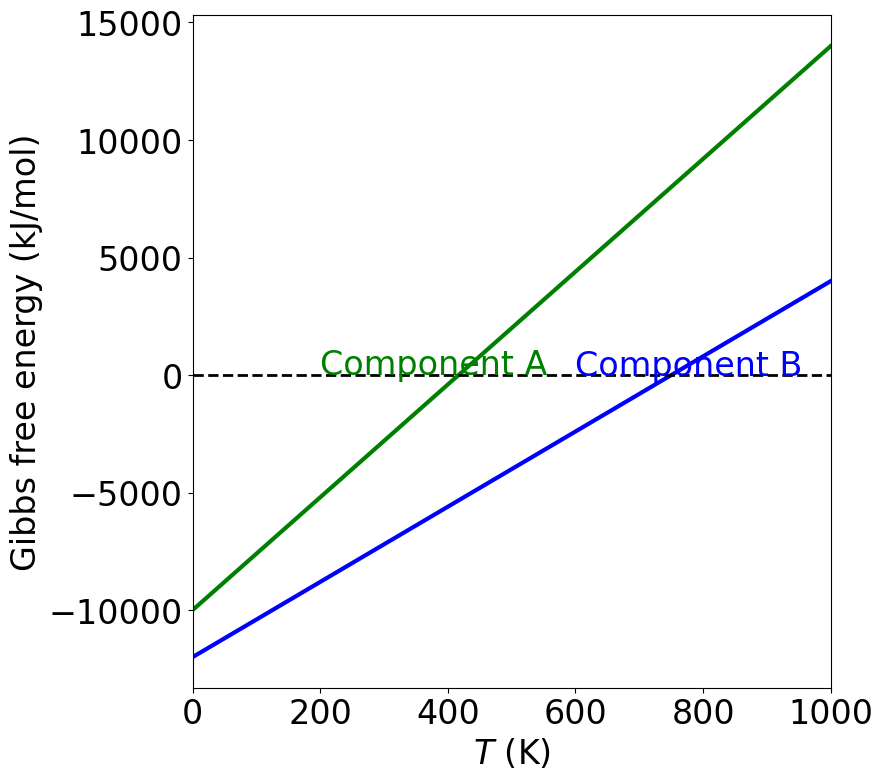

In [32]:
# Array of temperatures from 0 to 1000 K
Tv = np.linspace(0,1000,20)

# Difference in Gibbs free energy between the liquid and solid phase for the pure components A and B
# Assume that the Gibbs free energy difference is simply linear in temperature
def get_Gref(T, a, b):
    return a*T-b
    
aA = 24
bA = 10e3

aB = 16
bB = 12e3

GrefA = get_Gref(Tv, aA, bA)
GrefB = get_Gref(Tv, aB, bB)

def GrefA_func(T):
    return get_Gref(T, aA, bA)

def GrefB_func(T):
    return get_Gref(T, aB, bB)

TmA = newton(GrefA_func, 500)
TmB = newton(GrefB_func, 500)
print("Melting point\n  of component A = ", TmA, "\n  of component B = ", TmB)

# Plot Gibbs free energy difference between the solid and liquid phase
# for the pure components A and B
fig, ax = plt.subplots(1, 1, figsize=(8,8))
fig.tight_layout()

ax.plot(Tv, GrefA, 'g-', lw=3.0)
ax.plot(Tv, GrefB, 'b-', lw=3.0)
ax.plot([0, 1000], [0, 0], 'k--', linewidth=2.0)

ax.annotate('Component A', xy=(200,5), color='g', xycoords='data')
ax.annotate('Component B', xy=(600,-5), color='b', xycoords='data')

ax.set_xlim([0, 1000])
ax.set_xlabel('$T$ (K)')
ax.set_ylabel('Gibbs free energy (kJ/mol)')

plt.show()

### Gibbs free energies of the solid and liquid phase

Next, we use the regular solution model and the Gibbs free energy for the pure components to calculate the Gibbs free energy of the solid and liquid phases. The Gibbs free energy difference between the solid and liquid phase for the pure components A and B provides the correct references for the two Gibbs free energy curves. We select a temperature and plot the Gibbs free energy of the solid and liquid phases.

**Change the temperature and plot the Gibbs free energies of the solid and liquid phase.**

**What do you observe for temperatures below the melting point of both phases?**

**What do you observe for temperatures between the melting point of both phases?**

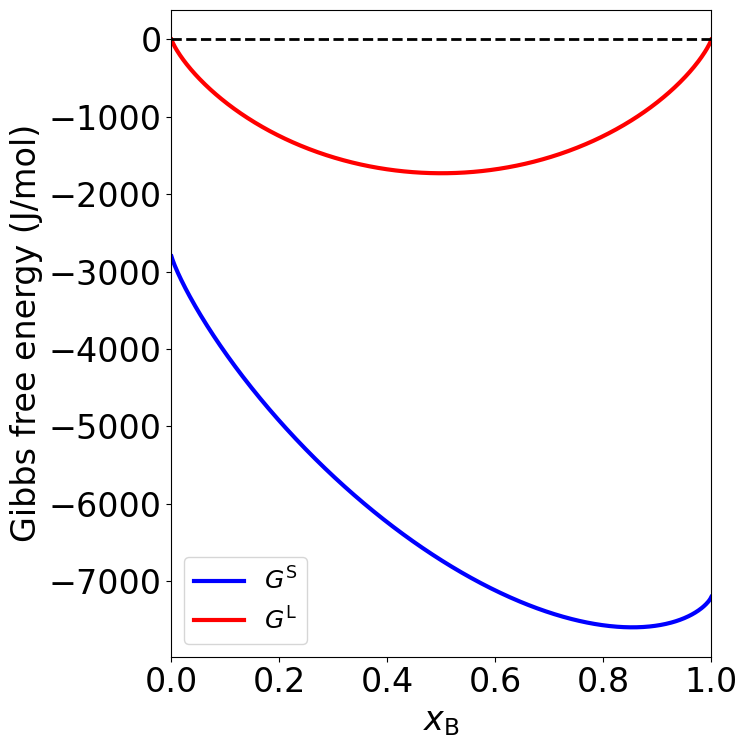

In [38]:
# Array of compositions from 0 to 1
xv = np.linspace(0.0001,0.9999,500)

# Set the temperature
T = 300 # K

# Gibbs free energy of mixing for the ideal solition model (a0=0)
Gmix_S = get_G_rs(T, 0.0, xv)
Gmix_L = get_G_rs(T, 0.0, xv)

# Reference Gibbs free energies for pure components
GrefA = get_Gref(T, aA, bA)
GrefB = get_Gref(T, aB, bB)

# Return the Gibbs free energy accounting for the reference states for A and B
# We select the liquid phase as the reference state for both pure components
def get_G_S(T, x):
    return get_G_rs(T, 0, x) + get_Gref(T, aA, bA)*(1-x) + get_Gref(T, aB, bB)*x

def get_G_L(T, x):
    return get_G_rs(T, 0, x)

G_S = get_G_S(T, xv)
G_L = get_G_L(T, xv)

# Plot Gibbs free energy for both phases
fig, ax = plt.subplots(1, 1, figsize=(8,8))
fig.tight_layout()

ax.plot(xv, G_S , 'b-', linewidth=3.0, label='$G^\\mathrm{S}$')
ax.plot(xv, G_L, 'r-', linewidth=3.0, label='$G^\\mathrm{L}$')
ax.plot([0, 1], [0, 0], 'k--', linewidth=2.0)
ax.set_xlim([0, 1])
ax.set_xlabel('$x_\\mathrm{B}$')
ax.set_ylabel('Gibbs free energy (J/mol)')
ax.legend(prop={'size': 18})

fig.tight_layout()
plt.show()

The choice of reference state is arbitrary and does not change the thermodynamics. In the above example, we use the liquid phase as the reference state for pure component A and B. Hence, the Gibbs free energy of the liquid phase goes to zero for $x_B = 0$ and $x_B = 1$.

**If we want to change the reference state for pure component A to be the solid phase, how would you modify the equations for the Gibbs free energy of the solid and liquid mixture?**

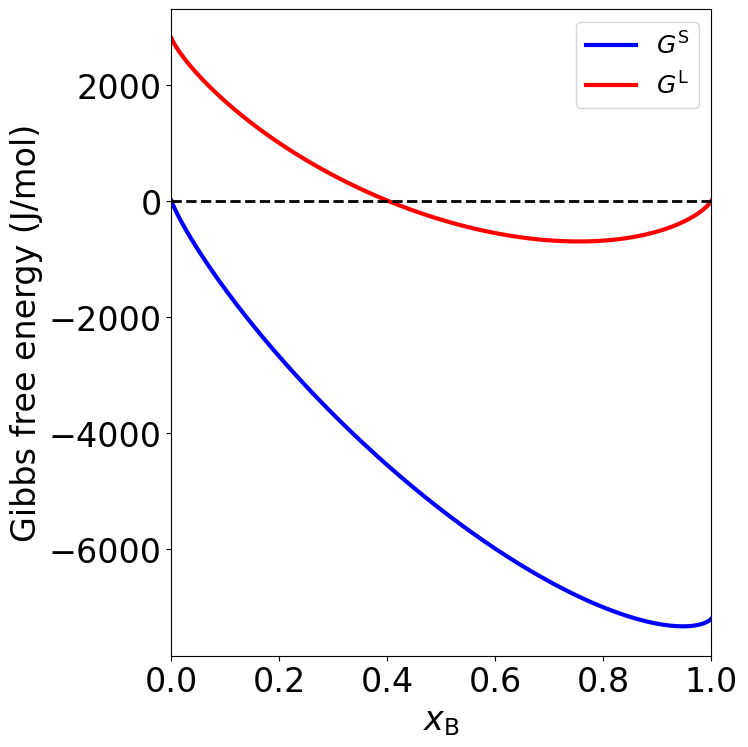

In [15]:
# Return the Gibbs free energy accounting for the reference states for A and B
# We select the liquid phase as the reference state for both pure components
def get_G_S(T, x):
    return get_G_rs(T, 0, x) + get_Gref(T, aB, bB)*x

def get_G_L(T, x):
    return get_G_rs(T, 0, x) - get_Gref(T, aA, bA)*(1-x)

G_S = get_G_S(T, xv)
G_L = get_G_L(T, xv)

# Plot Gibbs free energy for both phases
fig, ax = plt.subplots(1, 1, figsize=(8,8))
fig.tight_layout()

ax.plot(xv, G_S, 'b-', linewidth=3.0, label='$G^\\mathrm{S}$')
ax.plot(xv, G_L, 'r-', linewidth=3.0, label='$G^\\mathrm{L}$')
ax.plot([0, 1], [0, 0], 'k--', linewidth=2.0)
ax.set_xlim([0, 1])
ax.set_xlabel('$x_\\mathrm{B}$')
ax.set_ylabel('Gibbs free energy (J/mol)')
ax.legend(prop={'size': 18})

fig.tight_layout()
plt.show()

### Tangent intercept construction for the chemical potentials of A and B

Now we calculate the chemical potentials of components A and B for arbitrary mole fractions using the tangent intercept construction:
$$
\mu_A = G(x_B) - x_B \frac{dG(x_B)}{d x_B}
$$
and
$$
\mu_B = G(x_B) + (1-x_B) \frac{dG(x_B)}{d x_B}.
$$

**Modify the code to calculate also the tangent for the liquid phase and determine the chemical potentials of components A and B in the liquid phase.**

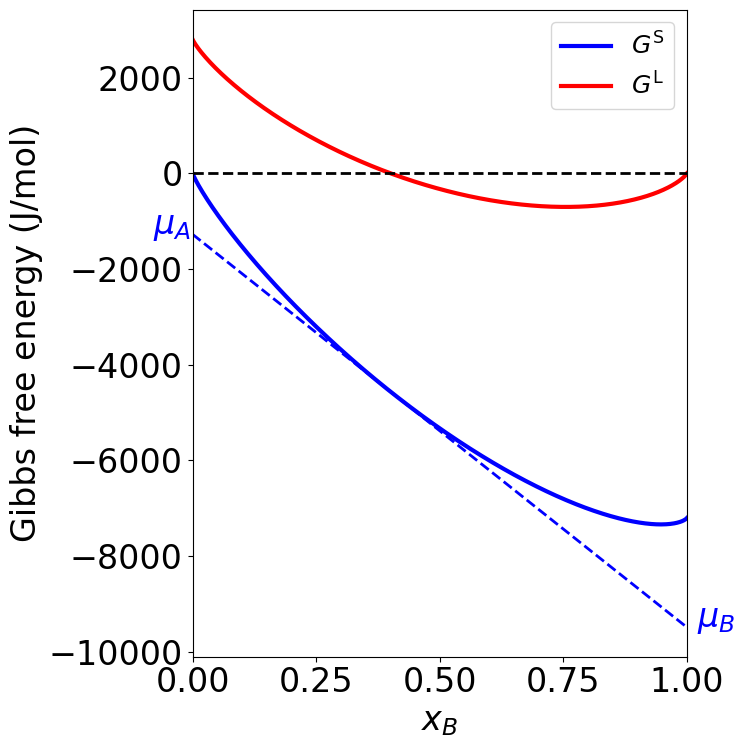

In [21]:
# Tangent to the Gibbs free energy curve

# Set the temperature
T = 300 # K

# Array of compositions from 0 to 1
xv = np.linspace(0.0001,0.9999,500)

G_S = get_G_S(T, xv)
G_L = get_G_L(T, xv)

# Tangent intercept construction of chemical potentials of components A and B

# Select a mole fraction
x = 0.4

# Calculate the derivative of G_S with respect to x
dx = 0.0001
dG_Sdx = (get_G_S(T, x+dx/2) - get_G_S(T, x-dx/2))/dx
mu_A = get_G_S(T, x) - x*dG_Sdx
mu_B = get_G_S(T, x) + (1-x)*dG_Sdx

# Plot Gibbs free energy for both phases
fig, ax = plt.subplots(1, 1, figsize=(8,8))
fig.tight_layout()

ax.plot(xv, G_S, 'b-', linewidth=3.0, label='$G^\\mathrm{S}$')
ax.plot(xv, G_L, 'r-', linewidth=3.0, label='$G^\\mathrm{L}$')
ax.plot([0, 1], [mu_A, mu_B], 'b--', linewidth=2.0)
ax.plot([0, 1], [0, 0], 'k--', linewidth=2.0)

ax.annotate('$\\mu_A$', xy=(-0.08, mu_A), color='b', xycoords='data', annotation_clip=False)
ax.annotate('$\\mu_B$', xy=(1.02,mu_B), color='b', xycoords='data', annotation_clip=False)

ax.set_xlim([0, 1])
ax.set_xlabel('$x_{B}$')
ax.set_ylabel('Gibbs free energy (J/mol)')
ax.legend(prop={'size': 18})
fig.tight_layout()
plt.show()

### Calculate a common tangent

Finally, we will calculate the common tangent to determine the chemical equilibrium between the solid and liquid phase. We will use the Python function `fsolve` to determine the mole fraction $x_B$ in the solid and liquid phase such that the chemical potentials in each phase are equal:
$$
\mu_A^S = \mu_A^L
$$
and
$$
\mu_B^S = \mu_B^L.
$$

**Calculate the equilibrium mole fractions in the solid and liquid phase for a range of temperatures and sketch out the phase diagram**

Common tangent construction:


<IPython.core.display.Math object>

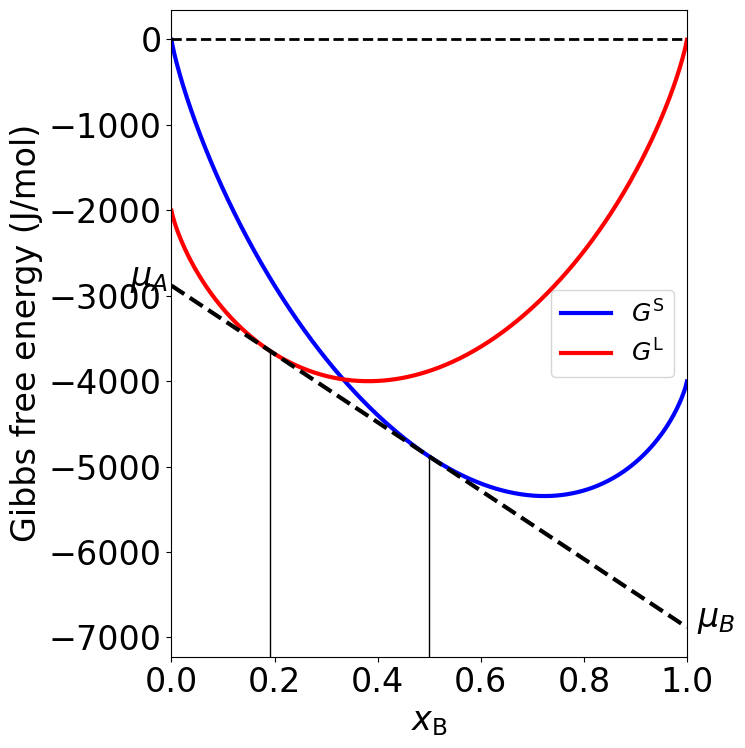

In [23]:
# Set the temperature
T = 500 # K

# Array of compositions from 0 to 1
xv = np.linspace(0.0001,0.9999,500)

G_S = get_G_S(T, xv)
G_L = get_G_L(T, xv)

# Return the chemical potentials of components A and B for the solid phase
def get_mu_S(T, x):
    dx = 0.0001
    dGdx = (get_G_S(T, x+dx/2) - get_G_S(T, x-dx/2))/dx
    mu_A = get_G_S(T, x) - x*dGdx
    mu_B = get_G_S(T, x) + (1-x)*dGdx
    return mu_A, mu_B

# Return the chemical potentials of components A and B for the liquid phase
def get_mu_L(T, x):
    dx = 0.0001
    dGdx = (get_G_L(T, x+dx/2) - get_G_L(T, x-dx/2))/dx
    mu_A = get_G_L(T, x) - x*dGdx
    mu_B = get_G_L(T, x) + (1-x)*dGdx
    return mu_A, mu_B

# Find the composition x such that mu_A^S = mu_A^L and mu_B^S = mu_B^L
def commontangent(p):
    x_S, x_L = p
    mu_A_S, mu_B_S = get_mu_S(T,x_S)
    mu_A_L, mu_B_L = get_mu_L(T,x_L)
    return (mu_A_S-mu_A_L), (mu_B_S-mu_B_L)

# May need to ensure that we use a reasonable starting guess
x_S, x_L =  fsolve(commontangent, (0.7, 0.3))

mu_A_S, mu_B_S = get_mu_S(T,x_S)
mu_A_L, mu_B_L = get_mu_L(T,x_L)

print('Common tangent construction:')
display(Math(r' x_S = {} \\ x_L = {}'.format(round(x_S,3), round(x_L,3))))

# Plot Gibbs free energy for both phases
fig, ax = plt.subplots(1, 1, figsize=(8,8))
fig.tight_layout()

ax.plot(xv, G_S, 'b-', linewidth=3.0, label='$G^\\mathrm{S}$')
ax.plot(xv, G_L, 'r-', linewidth=3.0, label='$G^\\mathrm{L}$')
ax.plot([0, 1], [mu_A_S, mu_B_S], 'k--', linewidth=3.0)
ax.plot([0, 1], [0, 0], 'k--', linewidth=2.0)

ax.annotate('$\\mu_A$', xy=(-0.08, mu_A_S), color='k', xycoords='data', annotation_clip=False)
ax.annotate('$\\mu_B$', xy=(1.02, mu_B_S), color='k', xycoords='data', annotation_clip=False)

ymin, ymax = ax.get_ylim()
ax.plot([x_S, x_S], [get_G_S(T, x_S), ymin], 'k-', linewidth=1.0)
ax.plot([x_L, x_L], [get_G_L(T, x_L), ymin], 'k-', linewidth=1.0)

ax.set_xlim([0, 1])
ax.set_ylim([ymin, ymax])
ax.set_xlabel('$x_\\mathrm{B}$')
ax.set_ylabel('Gibbs free energy (J/mol)')
ax.legend(prop={'size': 18})
fig.tight_layout()
plt.show()

# Calculation of the phase diagram using the common tangent construction

/var/folders/qg/fd6rwmln2ys1_p2s6xdh0b800000gn/T/ipykernel_38777/1814386533.py:6: RuntimeWarning: invalid value encountered in log
  S_id = -R * (x * np.log(x) + (1-x)*np.log(1-x))


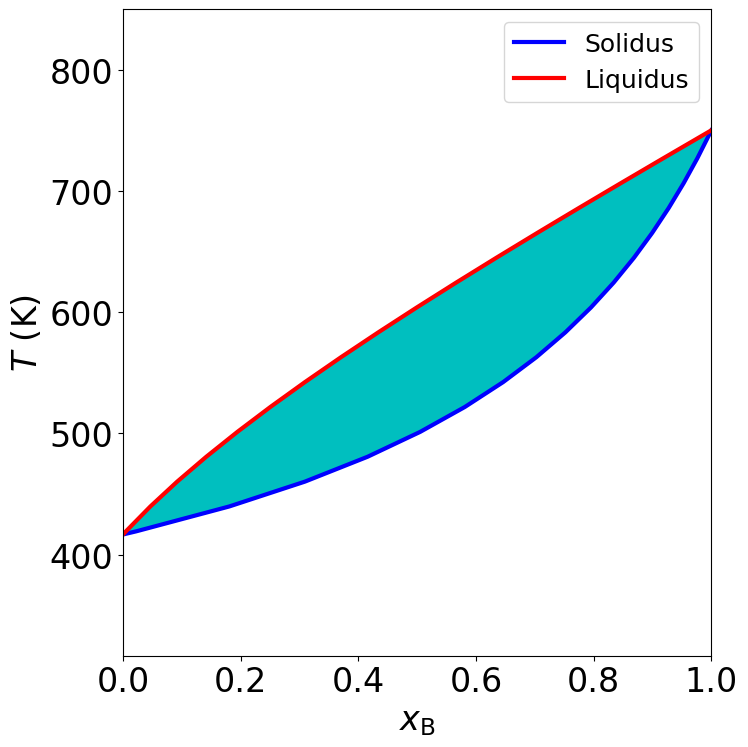

In [25]:
# Set the temperature
Tmin = TmA-100
Tmax = TmB+100
Tstep = 20
Npoints = int(np.abs(Tmax-Tmin)/Tstep+1)
Tv = np.linspace(Tmin, Tmax, Npoints)
Solidus = np.zeros(Npoints)
Liquidus = np.zeros(Npoints)
Temp = np.zeros(Npoints)

j=1

x1 = 0.95
x2 = 0.05
for i in range(Npoints):
    T = Tv[i]
    result =  fsolve(commontangent, (x1, x2), full_output=True)
    if result[2] in (1,2,3):
        x1, x2 = result[0]
        Solidus[j], Liquidus[j] = result[0]
        Temp[j] = T
        j = j+1

Solidus = np.resize(Solidus, j+1)
Liquidus = np.resize(Liquidus, j+1)
Temp = np.resize(Temp, j+1)
Solidus[0] = 0
Liquidus[0] = 0
Temp[0] = TmA
Solidus[j] = 1
Liquidus[j] = 1
Temp[j] = TmB

xboundary, yboundary = np.hstack((Liquidus, Solidus[::-1])), np.hstack((Temp, Temp[::-1]))

# Plot Phase Diagram
fig, ax = plt.subplots(1, 1, figsize=(8,8))
fig.tight_layout()

ax.plot(Solidus, Temp, 'b-', linewidth=3.0, label='Solidus')
ax.plot(Liquidus, Temp, 'r-', linewidth=3.0, label='Liquidus')
ax.fill(xboundary, yboundary, color='c', alpha=1)

ax.set_xlim([0, 1])
ax.set_ylim([Tmin, Tmax])
ax.set_xlabel('$x_\\mathrm{B}$')
ax.set_ylabel('$T$ (K)')
ax.legend(prop={'size': 18})
fig.tight_layout()
plt.show()